# Importing libraries

In [1]:
import numpy as np 
import pandas as pd 

import re    #for regural expressions->finding patterns in text, replacing text, extracting specific words
import nltk  #natural language toolkit->tokenizing text

#for converting the text into numeric
from sklearn.feature_extraction.text import TfidfVectorizer

#data
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#modeling algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
###neural network

#plots
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from wordcloud import WordCloud

from nltk.corpus import stopwords

# Loading the dataset

In [2]:
filename="/kaggle/input/datasets/mexwell/fake-reviews-dataset/fake reviews dataset.csv"
data=pd.read_csv(filename)
data.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


# Data preparation
### Checking for missing values

In [4]:
data.isnull().sum()

category    0
rating      0
label       0
text_       0
dtype: int64

No missing values. :)

## Deleting unneeded columns  
Since we are checking whether the text is Computer or Human written, the rating column only decribes sentiment. Also the category column is not needed.
They could introduce dataset bias and distract the models from learning textual characteristics.

In [5]:
data=data.drop(columns=["category","rating"])

In [6]:
data["label"].value_counts()

label
CG    20216
OR    20216
Name: count, dtype: int64

## Data analysis

(array([0, 1]), [Text(0, 0, 'CG'), Text(1, 0, 'OR')])

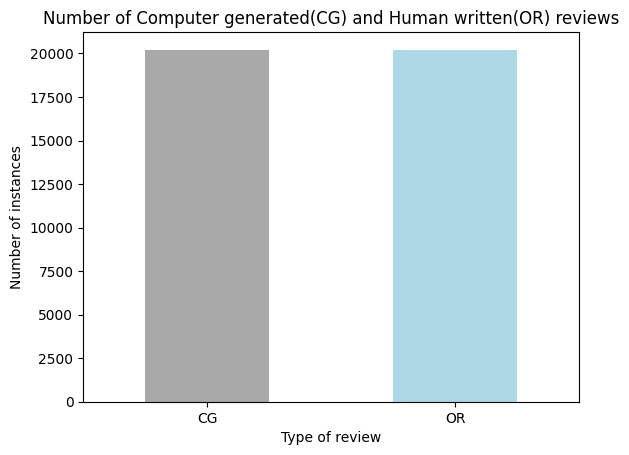

In [7]:
reviews_counts=data['label'].value_counts()

reviews_counts.plot(kind='bar', color=['darkgray','lightblue'])
plt.xlabel("Type of review")
plt.ylabel("Number of instances")
plt.title("Number of Computer generated(CG) and Human written(OR) reviews")
plt.xticks(rotation=0)

Same number of samples in both types of reviews.

### Converting the labels into numeric values
0-Human written original reviews(OR)  
1-Computer generated reviews(CG)

In [8]:
print(data['label'].unique())

['CG' 'OR']


In [9]:
data['label']=data['label'].map({
    'OR':0,
    'CG':1
})

In [10]:
data.head()

,label,text_
0,1,"Love this! Well made, sturdy, and very comfor..."
1,1,"love it, a great upgrade from the original. I..."
2,1,This pillow saved my back. I love the look and...
3,1,"Missing information on how to use it, but it i..."
4,1,Very nice set. Good quality. We have had the s...


## Cleaning the data
All text to lowercase, remove punctuation, remove numbers, remove extra spaces and tokenizing(spliting the data into words, and then joining back because TF-IDF needs the sentences as string

In [11]:
#stop_words=set(stopwords.words('english'))
def clean_text(text):
    text=text.lower()
    text=re.sub(r'\d+', '',text)    #remove numbers
    text=re.sub(r'[^\w\s]', '',text)  #remove punctuaiton
    words=text.split()   #tokenize

    #words=[word for word in words if word not in stop_words]
    
    text=" ".join(words)  #join back into sentence
    return text

### Apply the cleaning to all reviews

In [12]:
data['reviews']=data['text_'].apply(clean_text)

Data after cleaning:

In [13]:
print(data[['text_','reviews']].head())

                                               text_  \
0  Love this!  Well made, sturdy, and very comfor...   
1  love it, a great upgrade from the original.  I...   
2  This pillow saved my back. I love the look and...   
3  Missing information on how to use it, but it i...   
4  Very nice set. Good quality. We have had the s...   

                                             reviews  
0  love this well made sturdy and very comfortabl...  
1  love it a great upgrade from the original ive ...  
2  this pillow saved my back i love the look and ...  
3  missing information on how to use it but it is...  
4  very nice set good quality we have had the set...  


## Splitting the dataset

Split data into train/validation/test set  
60% train, 20% validation, 20% test 

In [14]:
X=data['reviews']
y=data['label']

#first split
X_temp, X_test, y_temp, y_test=train_test_split(
    X,y,test_size=0.2, random_state=42, stratify=y
)

#second split
X_train, X_val, y_train, y_val=train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

### TF-IDF vectorization

In [15]:
vectorizer=TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    #stop_words='english'
)

In [16]:
X_train_tfidf=vectorizer.fit_transform(X_train)
X_val_tfidf=vectorizer.transform(X_val)
X_test_tfidf=vectorizer.transform(X_test)

## Data modeling algorithms

### Decision tree classifier


Decision tree classifier accuracy: 0.7768022752565846

Test set result:
              precision    recall  f1-score   support

       0(OR)       0.77      0.80      0.78      4044
       1(CG)       0.79      0.76      0.77      4043

    accuracy                           0.78      8087
   macro avg       0.78      0.78      0.78      8087
weighted avg       0.78      0.78      0.78      8087


Confusion matrix:
[[3223  821]
 [ 984 3059]]


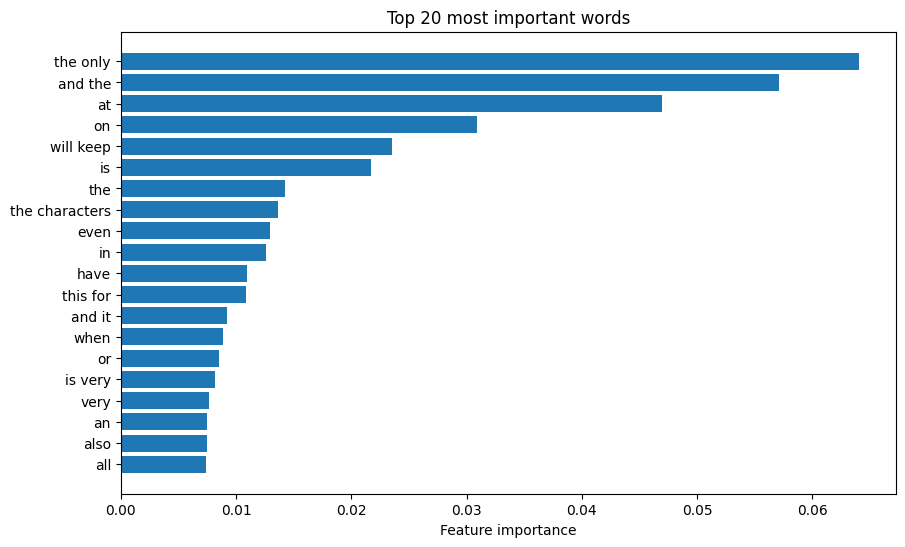

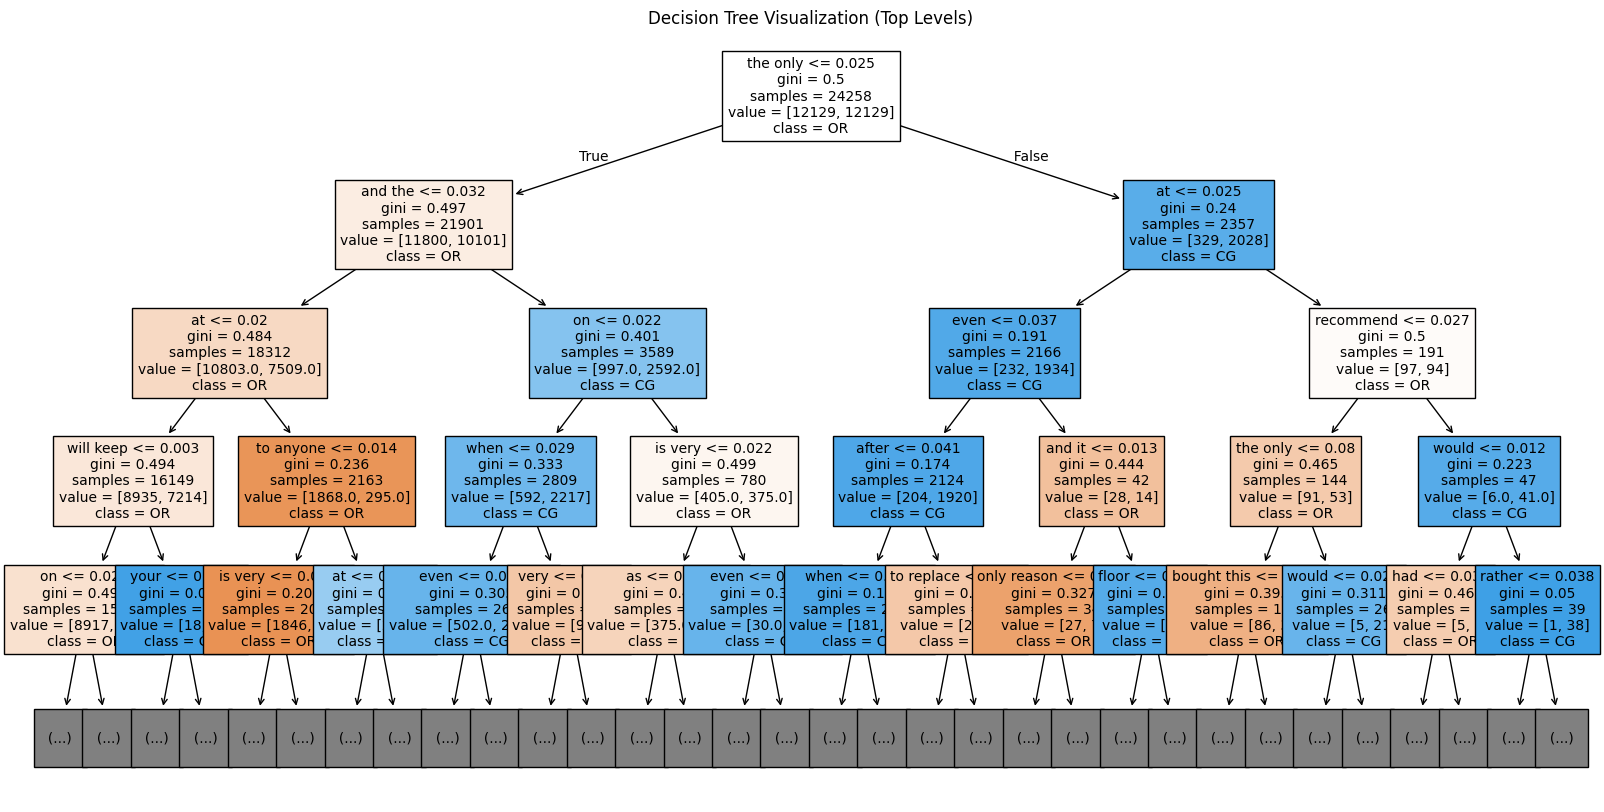

In [17]:
dt_model=DecisionTreeClassifier(
    max_depth=50,
    random_state=42
)
dt_model.fit(X_train_tfidf,y_train)

y_val_pred_dt=dt_model.predict(X_val_tfidf)
y_test_pred_dt=dt_model.predict(X_test_tfidf)

accuracy_dt=accuracy_score(y_test,y_test_pred_dt)
print("\nDecision tree classifier accuracy:",accuracy_dt)

print("\nTest set result:")
print(classification_report(y_test,y_test_pred_dt,target_names=['0(OR)','1(CG)']))

print("\nConfusion matrix:")
print(confusion_matrix(y_test,y_test_pred_dt))

#feature importance plot
importances=dt_model.feature_importances_
features=vectorizer.get_feature_names_out()
indices=np.argsort(importances)[-20:]
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)),importances[indices],align='center')
plt.yticks(range(len(indices)),[features[j] for j in indices])
plt.xlabel("Feature importance")
plt.title("Top 20 most important words")
plt.show()

#the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model, 
    filled=True,
    feature_names=vectorizer.get_feature_names_out(),  
    class_names=['OR', 'CG'], 
    max_depth=4,  
    fontsize=10
)
plt.title("Decision Tree Visualization (Top Levels)")
plt.show()

### Logistic regression


Logistic regression accuracy: 0.934586373191542

Test set result:
              precision    recall  f1-score   support

       0(OR)       0.93      0.94      0.94      4044
       1(CG)       0.94      0.92      0.93      4043

    accuracy                           0.93      8087
   macro avg       0.93      0.93      0.93      8087
weighted avg       0.93      0.93      0.93      8087


Confusion matrix:
[[3820  224]
 [ 305 3738]]


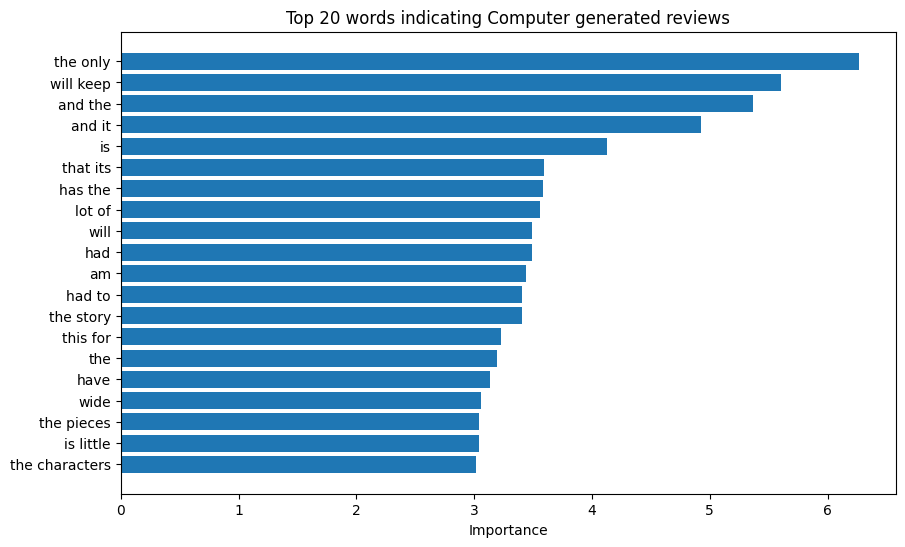

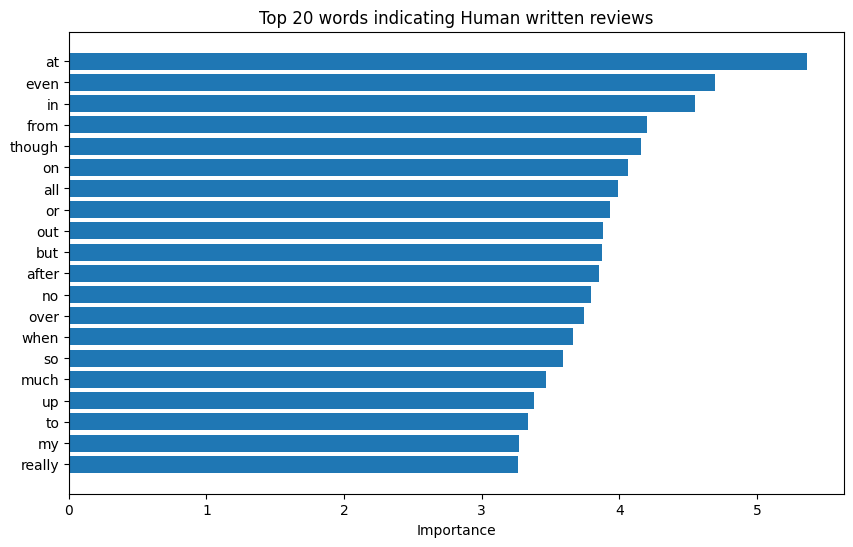

In [18]:
lr_model=LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_val_pred_lr=lr_model.predict(X_val_tfidf)
y_test_pred_lr=lr_model.predict(X_test_tfidf)

accuracy_lr=accuracy_score(y_test,y_test_pred_lr)
print("\nLogistic regression accuracy:",accuracy_lr)

print("\nTest set result:")
print(classification_report(y_test,y_test_pred_lr,target_names=['0(OR)','1(CG)']))

print("\nConfusion matrix:")
print(confusion_matrix(y_test,y_test_pred_lr))

#feature importance plots
coefficients=lr_model.coef_[0]

top_ai=np.argsort(coefficients)[-20:]
top_human=np.argsort(coefficients)[:20][::-1]

#AI feature importance plot
plt.figure(figsize=(10,6))
plt.barh(features[top_ai], np.abs(coefficients[top_ai]))
plt.title("Top 20 words indicating Computer generated reviews")
plt.xlabel("Importance")
plt.show()

#Human feature importance plot
plt.figure(figsize=(10,6))
plt.barh(features[top_human], np.abs(coefficients[top_human]))
plt.title("Top 20 words indicating Human written reviews")
plt.xlabel("Importance")
plt.show()

### Random forest classifier


Random forest classifier accuracy: 0.8979844194386052

Test set result:
              precision    recall  f1-score   support

          OR       0.87      0.93      0.90      4044
          CG       0.92      0.87      0.89      4043

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      8087
weighted avg       0.90      0.90      0.90      8087


Confussion matrix:
[[3760  284]
 [ 541 3502]]


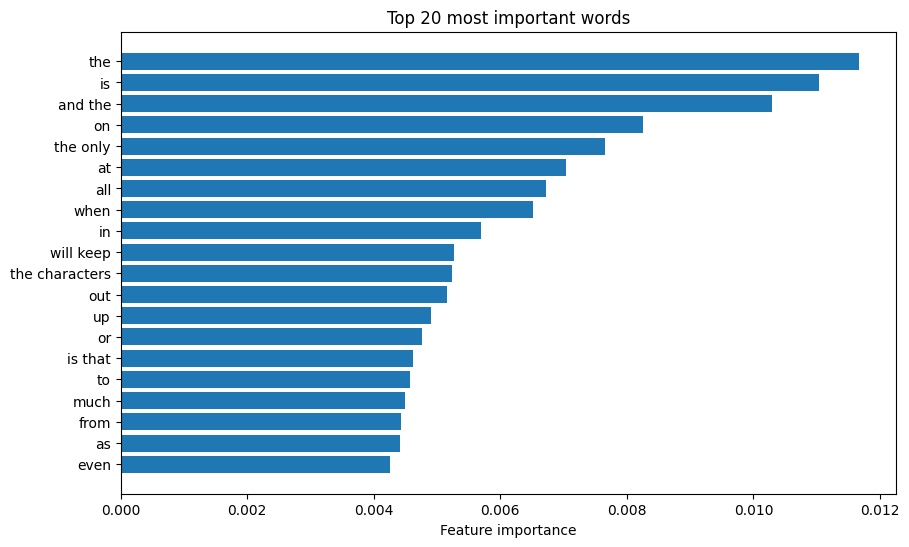

In [19]:
rf_model=RandomForestClassifier(
    n_estimators=100,
    max_depth=70,
    random_state=42,
    n_jobs=-1            #use all CPU cores
)
rf_model.fit(X_train_tfidf,y_train)

y_val_pred_rf=rf_model.predict(X_val_tfidf)
y_test_pred_rf=rf_model.predict(X_test_tfidf)

accuracy_rf=accuracy_score(y_test,y_test_pred_rf)
print("\nRandom forest classifier accuracy:",accuracy_rf)

print("\nTest set result:")
print(classification_report(y_test,y_test_pred_rf,target_names=['OR','CG']))

print("\nConfussion matrix:")
print(confusion_matrix(y_test,y_test_pred_rf))

#feature importance plot
importances=rf_model.feature_importances_
features=vectorizer.get_feature_names_out()
indices=np.argsort(importances)[-20:]
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)),importances[indices],align='center')
plt.yticks(range(len(indices)),[features[j] for j in indices])
plt.xlabel("Feature importance")
plt.title("Top 20 most important words")
plt.show()

### Histogram gradient boosting classifier

In [20]:
hgb_vectorizer=TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf_hgb=hgb_vectorizer.fit_transform(X_train)
X_val_tfidf_hgb=hgb_vectorizer.transform(X_val)
X_test_tfidf_hgb=hgb_vectorizer.transform(X_test)

#convert sparse tf-idf to dense(required)
X_train_dense=X_train_tfidf_hgb.toarray()
X_val_dense=X_val_tfidf_hgb.toarray()
X_test_dense=X_test_tfidf_hgb.toarray()

hgb_model=HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=50,
    learning_rate=0.1,
    random_state=42
)
hgb_model.fit(X_train_dense,y_train)

y_val_pred_hgb=hgb_model.predict(X_val_dense) 
y_test_pred_hgb=hgb_model.predict(X_test_dense)

accuracy_hgb=accuracy_score(y_test,y_test_pred_hgb)
print("\nHistogram Gradient Boosting classifier accuracy:",accuracy_hgb)

print("\nTest set result:")
print(classification_report(y_val,y_val_pred_hgb,target_names=['OR','CG']))

print("\nConfusion matrix:")
print(confusion_matrix(y_test,y_test_pred_hgb))


Histogram Gradient Boosting classifier accuracy: 0.9047854581426982

Test set result:
              precision    recall  f1-score   support

          OR       0.88      0.92      0.90      4043
          CG       0.92      0.88      0.90      4044

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      8087
weighted avg       0.90      0.90      0.90      8087


Confusion matrix:
[[3740  304]
 [ 466 3577]]


### K-Nearest Neighbors classifier

In [21]:
knn_model=KNeighborsClassifier(
    n_neighbors=5,
    metric='cosine',
)
knn_model.fit(X_train_tfidf,y_train)

y_val_pred_knn=knn_model.predict(X_val_tfidf)
y_test_pred_knn=knn_model.predict(X_test_tfidf)

accuracy_knn=accuracy_score(y_test,y_test_pred_knn)
print("\nK nearest neighbors classifier accuracy:",accuracy_knn)

print("\nTest set result:")
print(classification_report(y_test,y_test_pred_knn,target_names=['OR','CG']))

print("\nConfusion matrix:")
print(confusion_matrix(y_test,y_test_pred_knn))


K nearest neighbors classifier accuracy: 0.7423024607394584

Test set result:
              precision    recall  f1-score   support

          OR       0.93      0.52      0.67      4044
          CG       0.67      0.96      0.79      4043

    accuracy                           0.74      8087
   macro avg       0.80      0.74      0.73      8087
weighted avg       0.80      0.74      0.73      8087


Confusion matrix:
[[2118 1926]
 [ 158 3885]]
